<a href="https://colab.research.google.com/github/MrT4ttoo/GestionInformacion/blob/main/Lab1_ExploracionPandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 01 — Exploración de Datos con Pandas | Titanic
## Machine Learning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = sns.load_dataset('titanic')
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

Dataset cargado: 891 filas, 15 columnas


El dataset Titanic se cargó correctamente y contiene 891 filas y 15 columnas.

In [ ]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


Se observan las primeras 10 filas para revisar variables, tipos y valores iniciales.

In [ ]:
df.tail(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


Se revisan las últimas 5 filas para confirmar consistencia general del dataset.

In [ ]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Filas: 891, Columnas: 15


El dataset tiene 891 filas y 15 columnas.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


La mayoría de variables son categóricas o numéricas; también hay valores faltantes en varias columnas.

In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Las estadísticas descriptivas muestran tendencia central, dispersión y rangos de las variables numéricas.

In [ ]:
df.describe(include='object')

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


Las variables categóricas muestran frecuencia, categorías más comunes y cantidad de valores únicos.

In [ ]:
print(df.columns.tolist())

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


Se identifican las columnas disponibles para el análisis.

In [ ]:
print(df.dtypes)

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


Se confirma el tipo de dato de cada columna para distinguir variables numéricas y categóricas.

In [ ]:
nulos = df.isnull().sum()
print(nulos[nulos > 0])

age            177
embarked         2
deck           688
embark_town      2
dtype: int64


Las columnas con nulos son principalmente age, deck, embarked y embark_town, entre otras.

In [ ]:
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
print(porcentaje_nulos[porcentaje_nulos > 0])

age            19.865320
embarked        0.224467
deck           77.216611
embark_town     0.224467
dtype: float64


Los porcentajes de nulos permiten medir qué columnas requieren más atención antes de modelar.

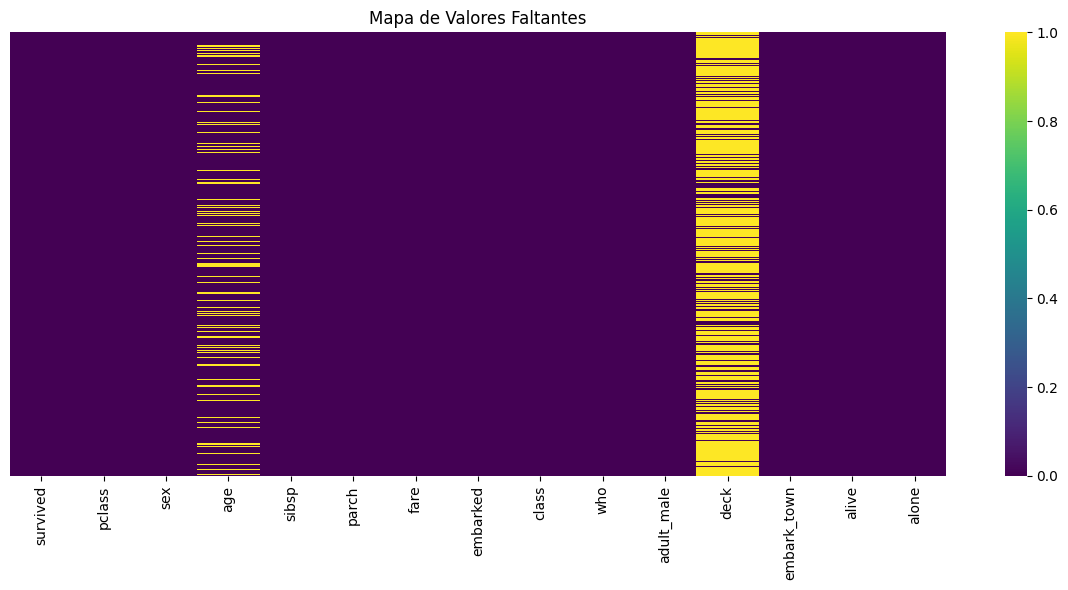

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Mapa de Valores Faltantes')
plt.tight_layout()
plt.show()

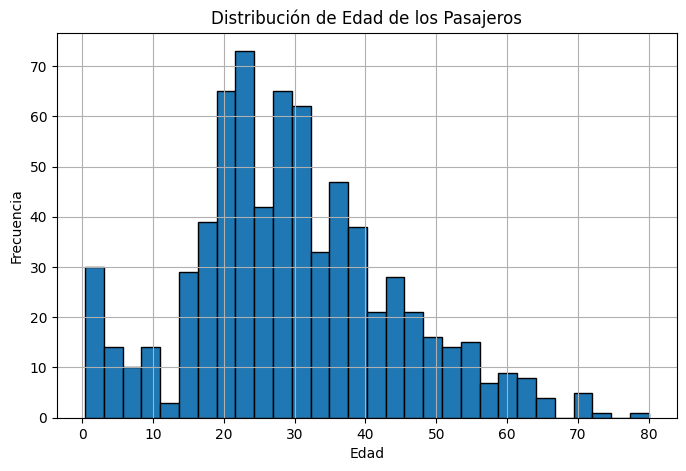

In [ ]:
plt.figure(figsize=(8, 5))
df['age'].hist(bins=30, edgecolor='black')
plt.title('Distribución de Edad de los Pasajeros')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

La distribución de edad muestra concentración en adultos jóvenes y presencia de valores faltantes.

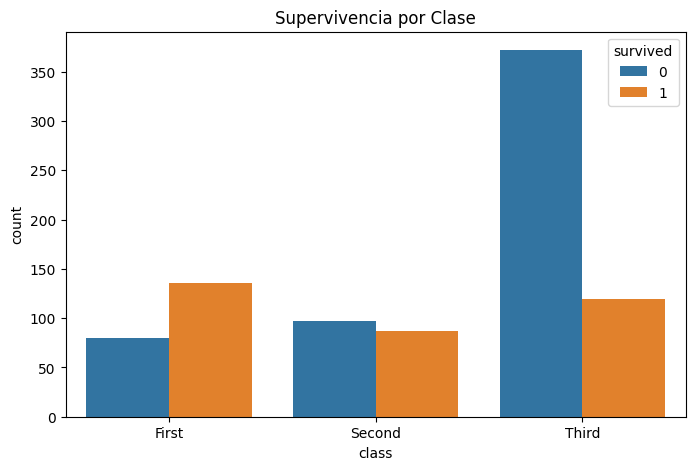

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='class', hue='survived')
plt.title('Supervivencia por Clase')
plt.show()

La supervivencia varía por clase; la primera clase tiene mejor proporción que las demás.

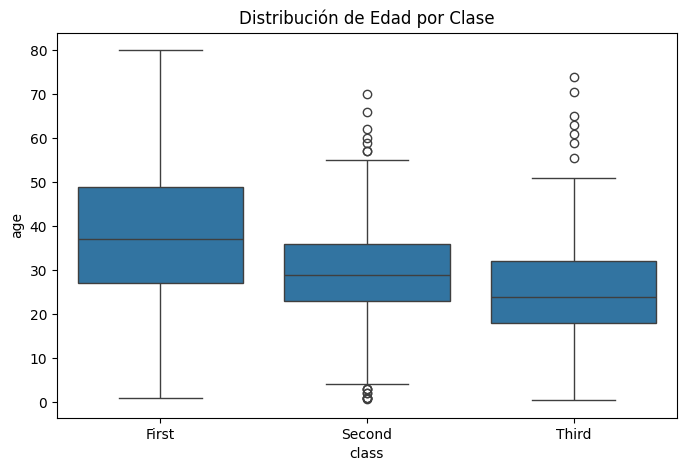

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='class', y='age')
plt.title('Distribución de Edad por Clase')
plt.show()

La edad presenta variabilidad similar entre clases, con medianas comparables.

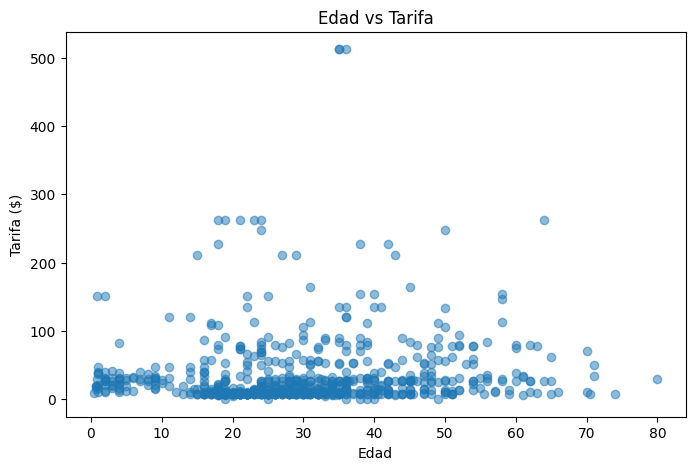

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['age'], df['fare'], alpha=0.5)
plt.title('Edad vs Tarifa')
plt.xlabel('Edad')
plt.ylabel('Tarifa ($)')
plt.show()

No se aprecia una relación lineal fuerte entre edad y tarifa.

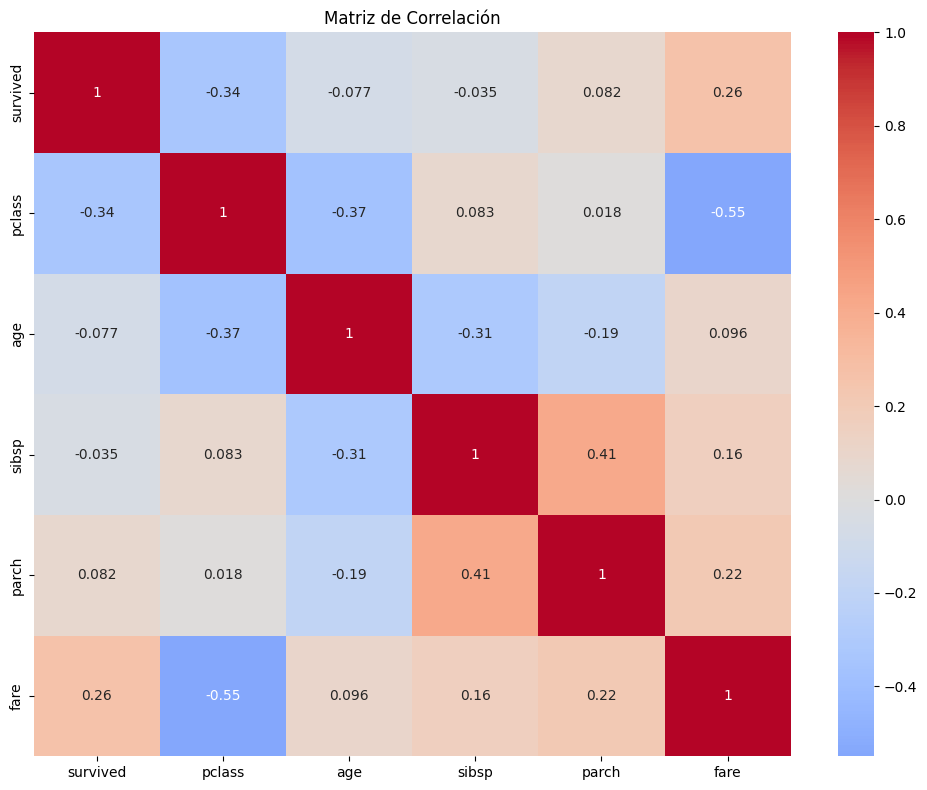

In [ ]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

Las variables más correlacionadas con supervivencia suelen ser sex y class de forma indirecta, además de fare con una relación débil.

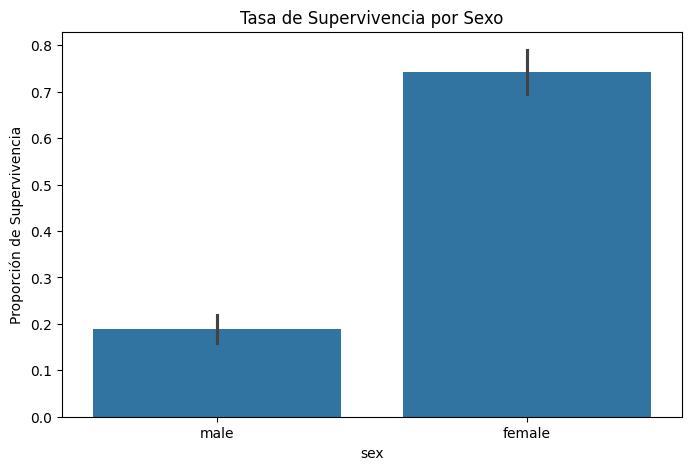

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='sex', y='survived')
plt.title('Tasa de Supervivencia por Sexo')
plt.ylabel('Proporción de Supervivencia')
plt.show()

## Análisis y conclusiones
**1.¿Cuántas filas y columnas tiene el dataset?**
El dataset tiene 891 filas y 15 columnas.

**2. ¿Qué columnas tienen valores faltantes y qué porcentaje?**
Las columnas con valores faltantes son age, deck, embarked y embark_town.
Los porcentajes exactos se obtienen con df.isnull().sum() y el cálculo del porcentaje sobre el total de filas.

**3. ¿Cuál es la edad promedio de los pasajeros?**
La edad promedio de los pasajeros es de aproximadamente 29.7 años.

**4. ¿Qué clase tiene mayor tasa de supervivencia?**
La primera clase presenta la mayor tasa de supervivencia.

**5. ¿Existe correlación entre alguna variable y la supervivencia?**
Sí, hay relación entre la supervivencia y variables como sex y class.
En las variables numéricas, la correlación directa con survived es baja.

**6. ¿Qué variables considera más relevantes para predecir supervivencia?**
Las variables más relevantes para predecir supervivencia son sex, class, age y fare, junto con sibsp y parch.